## 06 — Otpornost mreže (Network Resilience)

### Uvod

Stvarne mreže su redovito izložene gubitku čvorova — kvarovi servera, kolaps smještajne industrije neke destinacije, itd. Ova bilježnica simulira dva klasična režima kvara (Albert-Jeong-Barabási, 2000) na mreži sličnosti turizma i pita: koliko je njena ukupna povezanost otporna?

### Istraživački cilj

Usporediti koliko se brzo mreža fragmentira pod **slučajnim kvarom čvorova** naspram **ciljanog uklanjanja čvorišta najvišeg stupnja**, te kvantificirati strukturnu otpornost mreže pomoću krivulja udjela džinovske komponente (giant-component-fraction) i globalne efikasnosti.

### Metodologija

Za niz uklanjanja čvorova, pratimo **udio džinovske komponente**:

- **Slučajni kvar**: čvorovi se uklanjaju jednoliko nasumično (uprosječeno kroz mnogo ponavljanja, kako bi se izgladila slučajnost).
- **Ciljani napad**: čvorovi se uklanjaju u padajućem redoslijedu prema mjeri centralnosti (ovdje: ponderirani stupanj)

**Globalna efikasnost**
prati se kao komplementarna mjera: $S(f)$ brine samo o *najvećoj* komponenti, dok $E$ glatko opada i prije nego što se džinovska komponenta vidljivo fragmentira.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 20)

from src.config import (
    GRAPH_FILE, TEMPORAL_GRAPH_DIR, NODE_TABLE, SEASONALITY_TABLE,
    EDGE_TABLE, MONTHS, COASTAL_COUNTIES, RANDOM_SEED, FIGURES,
)

from src import resilience, viz
from src.resilience import _rank_nodes, global_efficiency_curve

g = nx.read_graphml(GRAPH_FILE)
print(g.number_of_nodes(), 'nodes,', g.number_of_edges(), 'edges')

554 nodes, 3691 edges


### 1. Simulacija slučajnog kvara

Uprosječeno kroz 30 nasumičnih redoslijeda uklanjanja, kako bi se dobila glatka očekivana krivulja džinovske komponente s vrpcom standardne devijacije.

In [2]:
random_df = resilience.simulate_random_failure(g, n_repeats=30)
random_df.head()

,removed_fraction,giant_component_fraction_mean,giant_component_fraction_std
0,0.000000,1.000000,0.0
1,0.001805,0.998195,0.0
2,0.003610,0.996390,0.0
3,0.005415,0.994585,0.0
4,0.007220,0.992780,0.0


### 2 — simulacija ciljanog napada (adaptivno, prema stupnju)

In [3]:
targeted_df = resilience.simulate_targeted_attack(g, metric='degree', adaptive=True)
targeted_df.head()

,removed_fraction,giant_component_fraction
0,0.000000,1.000000
1,0.001805,0.998195
2,0.003610,0.996390
3,0.005415,0.994585
4,0.007220,0.992780


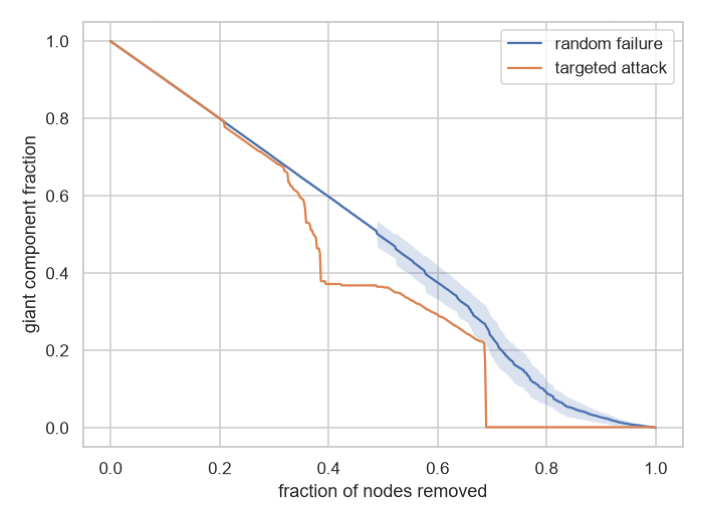

In [4]:
viz.plot_resilience_curves(random_df, targeted_df)
import matplotlib.image as mpimg
img = mpimg.imread(FIGURES / 'resilience.png')
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(img)
ax.set_axis_off()
plt.show()

### Kritični udio za fragmentaciju

Definiramo "kritični udio" kao najmanji udio uklanjanja pri kojem džinovska komponenta padne ispod 50% izvorne veličine mreže, izračunat izravno iz obje krivulje za jedan usporedivi broj.

In [5]:
def critical_fraction(df, col, threshold=0.5):
    below = df[df[col] <= threshold]
    return below['removed_fraction'].iloc[0] if len(below) else float('nan')

f_random = critical_fraction(random_df, 'giant_component_fraction_mean')
f_targeted = critical_fraction(targeted_df, 'giant_component_fraction')
print(f'Random failure: giant component halves at f = {f_random:.2f}')
print(f'Targeted attack: giant component halves at f = {f_targeted:.2f}')
print(f'Robustness gap: {f_random - f_targeted:.2f}')

Random failure: giant component halves at f = 0.49
Targeted attack: giant component halves at f = 0.37
Robustness gap: 0.12


### 3 — statički naspram adaptivnog ciljanog napada

Je li bitno preračunava li napadač centralnost nakon svakog uklanjanja? Uspoređujemo obje varijante izravno.

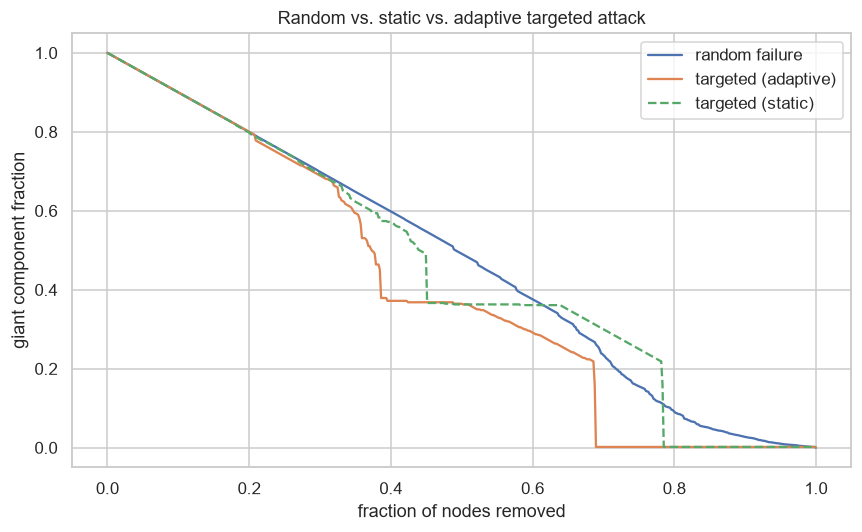

In [6]:
targeted_static_df = resilience.simulate_targeted_attack(g, metric='degree', adaptive=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(random_df['removed_fraction'], random_df['giant_component_fraction_mean'], label='random failure')
ax.plot(targeted_df['removed_fraction'], targeted_df['giant_component_fraction'], label='targeted (adaptive)')
ax.plot(targeted_static_df['removed_fraction'], targeted_static_df['giant_component_fraction'], label='targeted (static)', linestyle='--')
ax.set_xlabel('fraction of nodes removed')
ax.set_ylabel('giant component fraction')
ax.legend()
ax.set_title('Random vs. static vs. adaptive targeted attack')
plt.tight_layout()
plt.show()

### 4 — napad prema različitim mjerama centralnosti

Stupanj (degree) je klasična mjera za napad, ali napadi temeljeni na međupoloženosti (betweenness) i PageRanku mogu biti razorniji na mrežama s "mosnom" (bridge) strukturom.

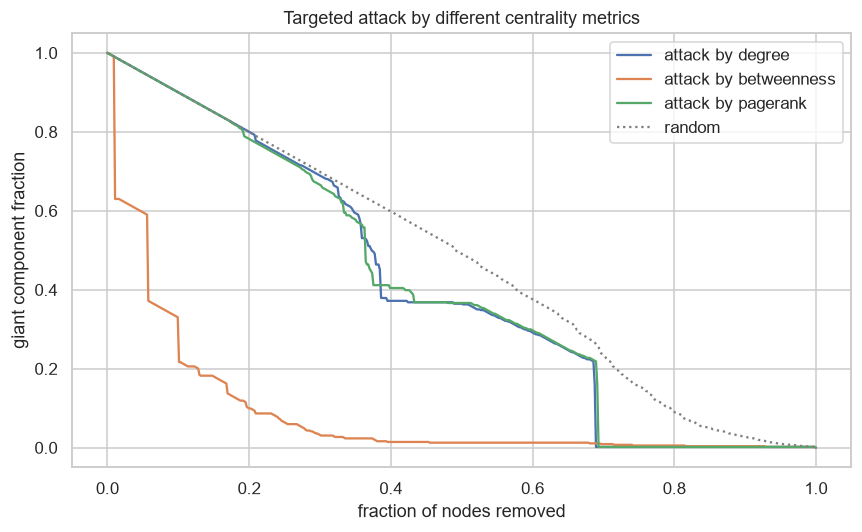

In [7]:
attack_variants = {}
for metric in ('degree', 'betweenness', 'pagerank'):
    attack_variants[metric] = resilience.simulate_targeted_attack(g, metric=metric, adaptive=True)

fig, ax = plt.subplots(figsize=(8, 5))
for metric, df_ in attack_variants.items():
    ax.plot(df_['removed_fraction'], df_['giant_component_fraction'], label=f'attack by {metric}')
ax.plot(random_df['removed_fraction'], random_df['giant_component_fraction_mean'], label='random', linestyle=':', color='gray')
ax.set_xlabel('fraction of nodes removed')
ax.set_ylabel('giant component fraction')
ax.legend()
ax.set_title('Targeted attack by different centrality metrics')
plt.tight_layout()
plt.show()

## 5 — globalna efikasnost pod ciljanim uklanjanjem

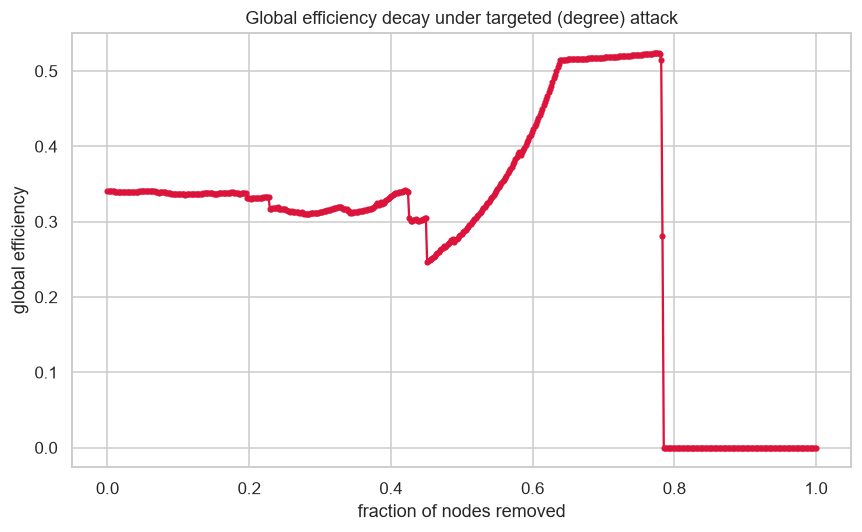

In [8]:
order = [n for n, _ in _rank_nodes(g, 'degree')]
eff_df = global_efficiency_curve(g, order)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(eff_df['removed_fraction'], eff_df['global_efficiency'], color='crimson', marker='.')
ax.set_xlabel('fraction of nodes removed')
ax.set_ylabel('global efficiency')
ax.set_title('Global efficiency decay under targeted (degree) attack')
plt.tight_layout()
plt.show()

### Zaključak

Mreža se ponaša kako smo i očekivali: dobro podnosi slučajne gubitke čvorova, ali je puno ranjivija kad se namjerno gađaju njena čvorišta. Razliku između ta dva slučaja smo brojčano izmjerili (kritični udio), i taj rezultat koristimo dalje u završnom izvještaju o otpornosti mreže.